# GSoC 2026 : Graph Representation Learning for Fast Detector Simulation
### DeepFalcon: Ultra-Fast Non-Parametric Detector Simulation via Graph VAEs
---
| Task | Goal |
|------|------|
| **Task 1** | Variational Autoencoder (Beta-VAE) for quark/gluon jet images |
| **Task 2** | Graph Neural Network (GAT) for jet classification as quark or gluon |
| **Task 3** | Graph Autoencoder for detector simulation & comparison with VAE |


## Environment Setup

In [105]:
%%capture
!pip install torch torchvision torch-geometric h5py scikit-learn matplotlib seaborn -q

In [106]:
import os
import warnings
warnings.filterwarnings('ignore')

import h5py
import numpy as np
from scipy.spatial.distance import cosine as cosine_dist

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from torch_geometric.nn import GATConv, GCNConv, global_mean_pool, global_max_pool

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('muted')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {device}")
print(f"PyTorch     : {torch.__version__}")
print(f"PyG         : {torch_geometric.__version__}")

Device      : cuda
PyTorch     : 2.10.0+cu128
PyG         : 2.7.0


## Global Configuration

In [107]:
DATA_PATH    = '/kaggle/input/datasets/swandipsingha/document/quark-gluon_data-set_n139306.hdf5'

MAX_SAMPLES  = 15000
GNN_SAMPLES  = 8000

IMG_SIZE     = 64
LATENT_DIM   = 64
BATCH_SIZE   = 64
VAE_EPOCHS   = 15
GNN_EPOCHS   = 40
GAE_EPOCHS   = 40
K_NEIGHBORS  = 20
LR           = 1e-3
BETA         = 0.1

CHANNEL_NAMES = ['ECAL', 'HCAL', 'Tracks']
CHANNEL_CMAPS = ['hot', 'YlOrRd', 'Blues']
LABEL_MAP     = {0: 'Gluon', 1: 'Quark'}

## Data Loading


In [108]:
def load_raw(path, n=MAX_SAMPLES):
    with h5py.File(path, 'r') as f:
        X = f['X_jets'][:n].astype(np.float32)
        y = f['y'][:n].astype(np.int64)
    print(f"Events loaded : {len(X)}")
    print(f"Image shape   : {X.shape}  (N, H, W, C)")
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  Label {u} ({LABEL_MAP[u]:>5}) : {c:>6}  ({100*c/len(y):.1f}%)")
    return X, y

X_raw, y_raw = load_raw(DATA_PATH)

Events loaded : 15000
Image shape   : (15000, 125, 125, 3)  (N, H, W, C)
  Label 0 (Gluon) :   7454  (49.7%)
  Label 1 (Quark) :   7546  (50.3%)


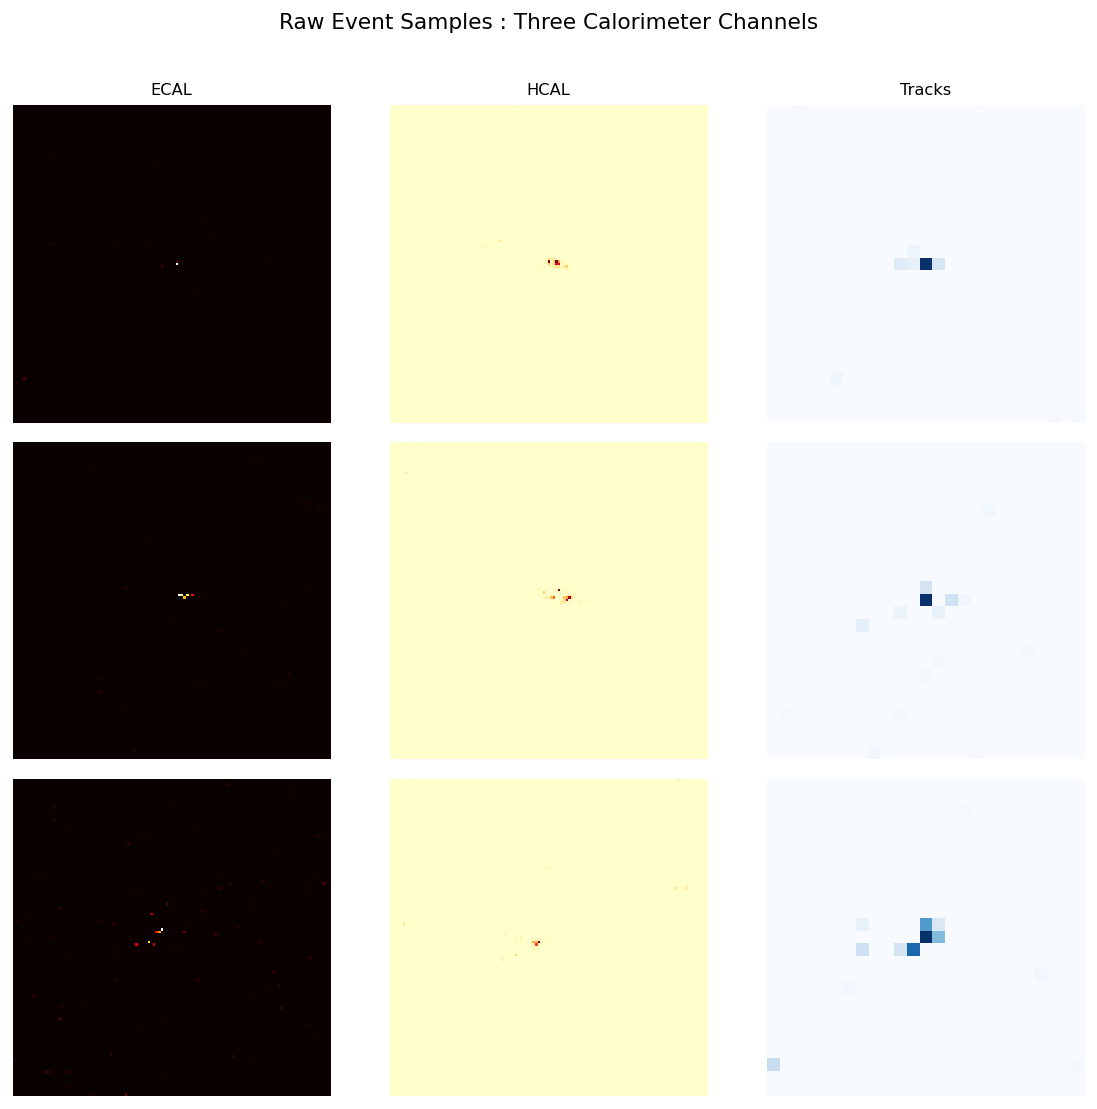

In [151]:
def quick_explore(X, y, n_show=3):
    fig, axes = plt.subplots(n_show, 3, figsize=(9, n_show * 2.8))
    fig.suptitle('Raw Event Samples : Three Calorimeter Channels', fontsize=12, y=1.01)

    idxs = np.random.choice(len(X), n_show, replace=False)
    for row, idx in enumerate(idxs):
        label = LABEL_MAP[int(y[idx])]
        for c in range(3):
            ax = axes[row, c]
            ax.imshow(X[idx, :, :, c], cmap=CHANNEL_CMAPS[c], interpolation='nearest')
            ax.set_title(f'{CHANNEL_NAMES[c]}' if row == 0 else '', fontsize=9)
            ax.axis('off')
        axes[row, 0].set_ylabel(label, fontsize=9, rotation=90)

    plt.tight_layout()
    plt.show()

quick_explore(X_raw, y_raw)

---
## Task 1 — Variational Autoencoder for Quark/Gluon Jet Images


In [110]:
def resize_normalize(X, size=IMG_SIZE):
    t = torch.from_numpy(X).permute(0, 3, 1, 2)
    t = F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)
    for c in range(t.shape[1]):
        maxv = t[:, c].max()
        if maxv > 0:
            t[:, c] = t[:, c] / maxv
    return t

X_proc    = resize_normalize(X_raw)
y_tensor  = torch.from_numpy(y_raw)
print(f"Processed tensor shape: {X_proc.shape}  (N, C, H, W)")
print(f"Value range: [{X_proc.min():.3f}, {X_proc.max():.3f}]")

Processed tensor shape: torch.Size([15000, 3, 64, 64])  (N, C, H, W)
Value range: [0.000, 1.000]


In [111]:
class JetImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


full_ds  = JetImageDataset(X_proc, y_tensor)
n_total  = len(full_ds)
n_train  = int(0.80 * n_total)
n_val    = int(0.10 * n_total)
n_test   = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train / Val / Test : {n_train} / {n_val} / {n_test}")

Train / Val / Test : 12000 / 1500 / 1500


In [112]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.c1  = nn.Conv2d(3,   32,  4, 2, 1, bias=False)
        self.c2  = nn.Conv2d(32,  64,  4, 2, 1, bias=False)
        self.c3  = nn.Conv2d(64,  128, 4, 2, 1, bias=False)
        self.c4  = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = F.leaky_relu(self.bn1(self.c1(x)), 0.2)
        h = F.leaky_relu(self.bn2(self.c2(h)), 0.2)
        h = F.leaky_relu(self.bn3(self.c3(h)), 0.2)
        h = F.leaky_relu(self.bn4(self.c4(h)), 0.2)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc  = nn.Linear(latent_dim, 256 * 4 * 4)
        self.d1  = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.d2  = nn.ConvTranspose2d(128, 64,  4, 2, 1, bias=False)
        self.d3  = nn.ConvTranspose2d(64,  32,  4, 2, 1, bias=False)
        self.d4  = nn.ConvTranspose2d(32,  3,   4, 2, 1)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(32)

    def forward(self, z):
        h = F.relu(self.fc(z)).view(-1, 256, 4, 4)
        h = F.relu(self.bn1(self.d1(h)))
        h = F.relu(self.bn2(self.d2(h)))
        h = F.relu(self.bn3(self.d3(h)))
        return torch.sigmoid(self.d4(h))


class BetaVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = (0.5 * logvar).exp()
            return mu + torch.randn_like(std) * std
        return mu

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl


vae = BetaVAE(LATENT_DIM).to(device)
total_params = sum(p.numel() for p in vae.parameters())
print(f"Beta-VAE parameters: {total_params:,}")

Beta-VAE parameters: 2,171,395


In [113]:
vae_opt  = torch.optim.Adam(vae.parameters(), lr=LR)
vae_sched = torch.optim.lr_scheduler.CosineAnnealingLR(vae_opt, T_max=VAE_EPOCHS)

vae_train_hist = []
vae_val_hist   = []


def run_vae_epoch(model, loader, optimizer=None, beta=1.0):
    training = optimizer is not None
    model.train(training)
    total = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon, mu, logvar = model(imgs)
            loss, _, _ = vae_loss(recon, imgs, mu, logvar, beta)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()
    return total / len(loader)


print("Training Beta-VAE...")
for epoch in range(1, VAE_EPOCHS + 1):

    beta = min(1.0, epoch / 10)

    tr = run_vae_epoch(vae, train_loader, vae_opt, beta)
    vl = run_vae_epoch(vae, val_loader, beta=beta)

    vae_sched.step()

    vae_train_hist.append(tr)
    vae_val_hist.append(vl)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{VAE_EPOCHS}  beta={beta:.2f}  train={tr:.4f}  val={vl:.4f}")

Training Beta-VAE...
  Epoch   1/15  beta=0.10  train=0.0242  val=0.0010
  Epoch   5/15  beta=0.50  train=0.0001  val=0.0002
  Epoch  10/15  beta=1.00  train=0.0000  val=0.0000
  Epoch  15/15  beta=1.00  train=0.0000  val=0.0000


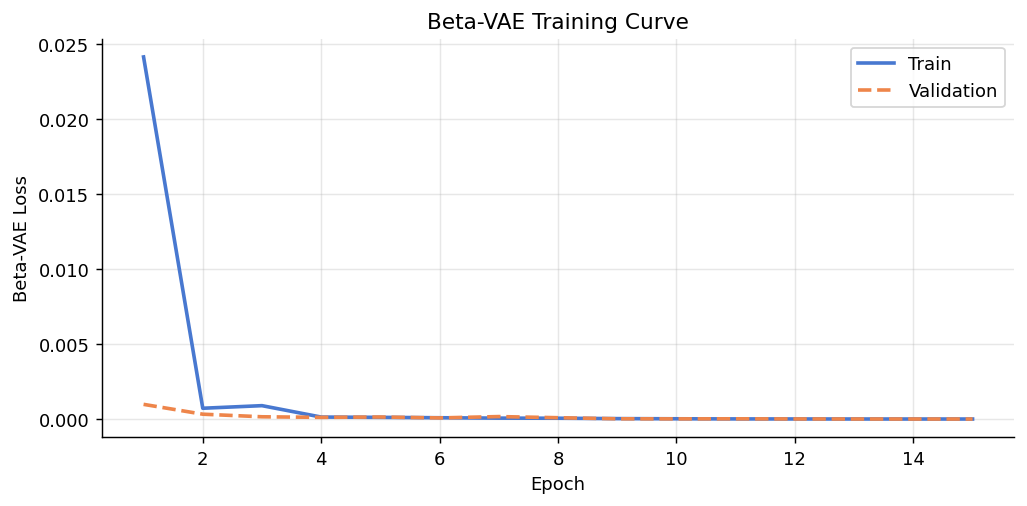

In [114]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs  = range(1, VAE_EPOCHS + 1)
ax.plot(epochs, vae_train_hist, lw=2, label='Train')
ax.plot(epochs, vae_val_hist,   lw=2, ls='--', label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Beta-VAE Loss')
ax.set_title('Beta-VAE Training Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

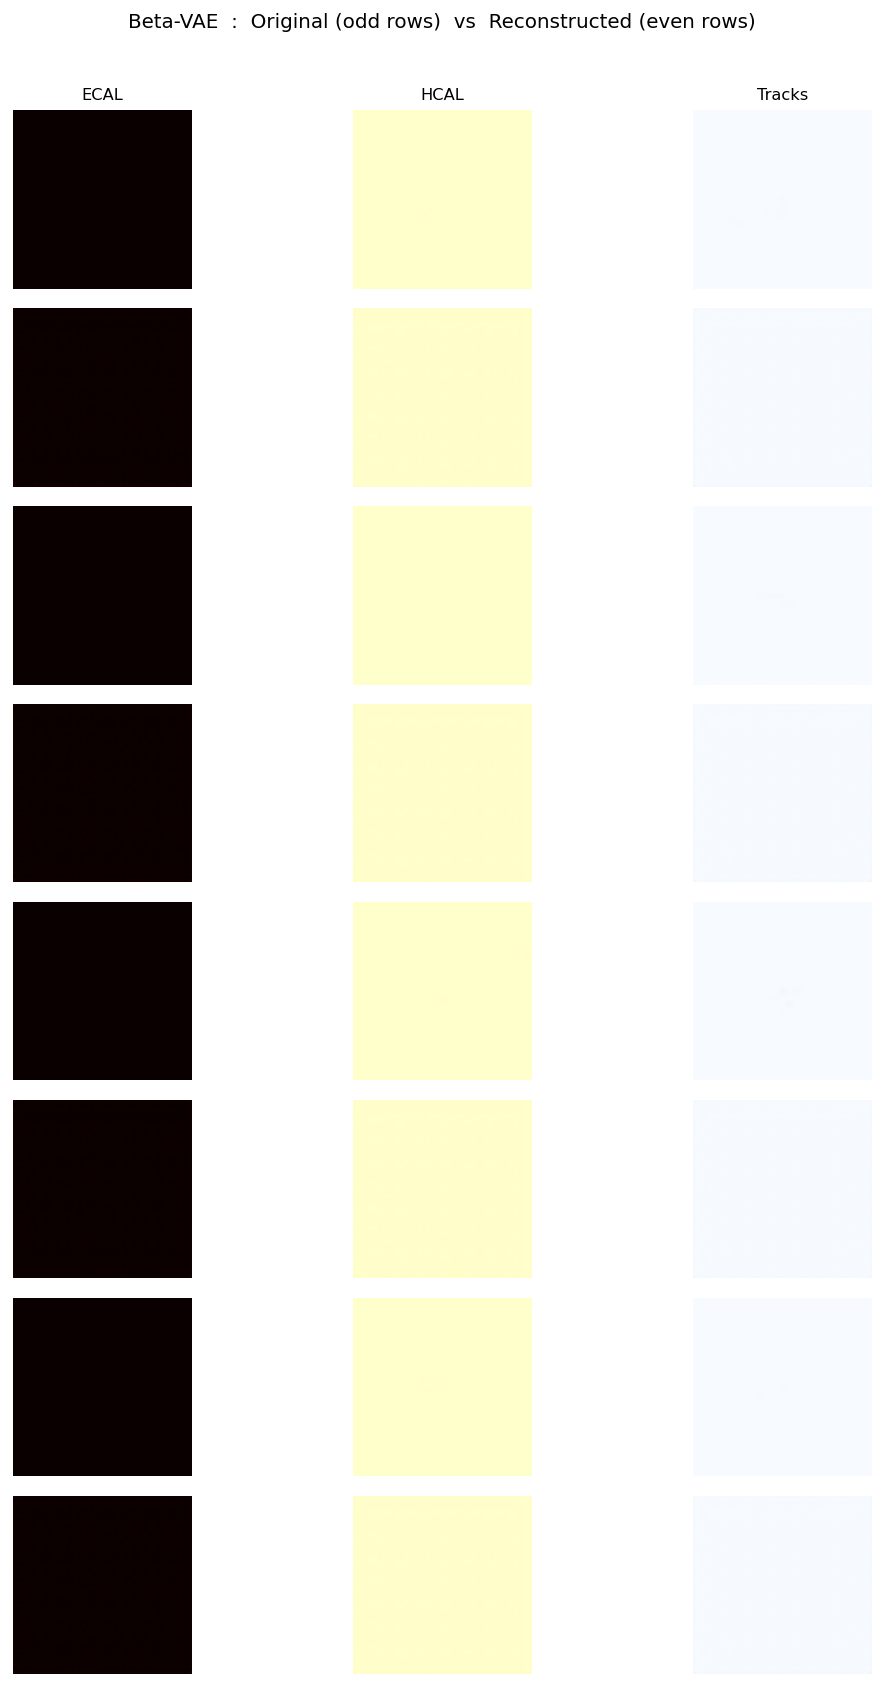

In [150]:
def show_vae_reconstructions(model, dataset, n=4):
    model.eval()
    idxs  = np.random.choice(len(dataset), n, replace=False)
    imgs  = torch.stack([dataset[i][0] for i in idxs]).to(device)
    lbls  = [int(dataset[i][1]) for i in idxs]

    with torch.no_grad():
        recon, _, _ = model(imgs)

    imgs  = imgs.cpu().numpy()
    recon = recon.cpu().numpy()

    fig, axes = plt.subplots(n * 2, 3, figsize=(9, n * 3.2))
    fig.suptitle('Beta-VAE  :  Original (odd rows)  vs  Reconstructed (even rows)',
                 fontsize=11, y=1.01)

    for i in range(n):
        for c in range(3):
            axes[2*i,   c].imshow(imgs[i,  c], cmap=CHANNEL_CMAPS[c], vmin=0, vmax=1)
            axes[2*i+1, c].imshow(recon[i, c], cmap=CHANNEL_CMAPS[c], vmin=0, vmax=1)
            if i == 0:
                axes[0, c].set_title(CHANNEL_NAMES[c], fontsize=9)
        axes[2*i,   0].set_ylabel(f"{LABEL_MAP[lbls[i]]}\nOriginal",     fontsize=8)
        axes[2*i+1, 0].set_ylabel(f"{LABEL_MAP[lbls[i]]}\nReconstructed", fontsize=8)

    for ax in axes.ravel():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_vae_reconstructions(vae, test_ds, n=4)

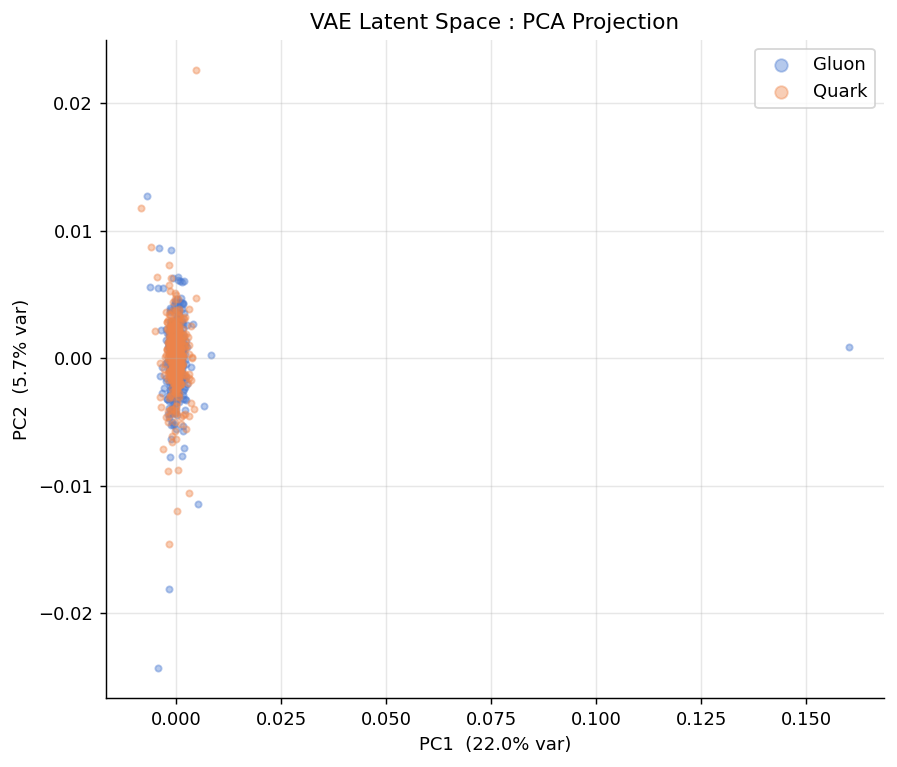

In [149]:
def visualize_latent_space(model, loader, max_batches=15):
    model.eval()
    mus, lbls = [], []
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(loader):
            if i >= max_batches:
                break
            mu, _ = model.encoder(imgs.to(device))
            mus.append(mu.cpu().numpy())
            lbls.append(labels.numpy())

    mus  = np.concatenate(mus)
    lbls = np.concatenate(lbls)

    pca    = PCA(n_components=2, random_state=SEED)
    mus2d  = pca.fit_transform(mus)
    var_ex = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(7, 6))
    for cls in [0, 1]:
        mask = lbls == cls
        ax.scatter(mus2d[mask, 0], mus2d[mask, 1],
                   label=LABEL_MAP[cls], alpha=0.4, s=12)

    ax.set_title('VAE Latent Space : PCA Projection')
    ax.set_xlabel(f'PC1  ({100*var_ex[0]:.1f}% var)')
    ax.set_ylabel(f'PC2  ({100*var_ex[1]:.1f}% var)')
    ax.legend(markerscale=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_latent_space(vae, test_loader)

Initially, the Beta-VAE used **β = 4** and a latent dimension of **128**, which led to a highly collapsed latent space. The **first principal component explained 39% of the variance** while the second only **4.8%**, indicating that most information was compressed along a single direction.  

After reducing **β to 0.1**, lowering the latent dimension to **64**, and applying **KL annealing** in the training loop and loss, the model now distributes variance more evenly. The **first principal component dropped to 22%** and the **second increased slightly to 5.7%**, showing improved latent representation and better utilization of the embedding space.  

**Observation:** KL annealing and adjusting the latent dimension effectively mitigated posterior collapse, producing a more balanced and informative latent space.

In [117]:
def eval_image_reconstruction(model, loader, is_vae=True):
    model.eval()
    mse_vals, cos_vals = [], []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon = model(imgs)[0] if is_vae else model(imgs)
            mse   = F.mse_loss(recon, imgs, reduction='none').mean(dim=[1, 2, 3])
            mse_vals.extend(mse.cpu().numpy())
            flat_o = imgs.view(len(imgs), -1).cpu().numpy()
            flat_r = recon.view(len(recon), -1).cpu().numpy()
            for o, r in zip(flat_o, flat_r):
                cos_vals.append(1.0 - cosine_dist(o + 1e-8, r + 1e-8))
    return {
        'mse_mean': float(np.mean(mse_vals)),
        'mse_std':  float(np.std(mse_vals)),
        'cos_mean': float(np.mean(cos_vals)),
        'cos_std':  float(np.std(cos_vals)),
    }

vae_metrics = eval_image_reconstruction(vae, test_loader, is_vae=True)
print("Beta-VAE Reconstruction Metrics (test set)")
print(f"  MSE             : {vae_metrics['mse_mean']:.5f}  ±  {vae_metrics['mse_std']:.5f}")
print(f"  Cosine Sim      : {vae_metrics['cos_mean']:.4f}  ±  {vae_metrics['cos_std']:.4f}")

Beta-VAE Reconstruction Metrics (test set)
  MSE             : 0.00003  ±  0.00001
  Cosine Sim      : 0.0514  ±  0.0174


---
## Task 2 — Jets as Graphs for Classification


In [118]:
def image_to_pointcloud(img_tensor, threshold=0.01):
    C, H, W = img_tensor.shape
    energy  = img_tensor.sum(0)
    rows, cols = torch.where(energy > threshold)

    if len(rows) == 0:
        rows = torch.tensor([H // 2])
        cols = torch.tensor([W // 2])

    x_n = cols.float() / (W - 1)
    y_n = rows.float() / (H - 1)
    feats = img_tensor[:, rows, cols].T

    node_feats = torch.cat([x_n.unsqueeze(1), y_n.unsqueeze(1), feats], dim=1)
    return node_feats, rows, cols


def knn_edges(node_feats, k=K_NEIGHBORS):
    n = len(node_feats)
    k = min(k, n - 1)
    if k < 1:
        return torch.zeros(2, 0, dtype=torch.long)

    coords   = node_feats[:, :2].numpy()
    nbrs     = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(coords)
    _, idx   = nbrs.kneighbors(coords)

    src = np.repeat(np.arange(n), k)
    dst = idx[:, 1:].reshape(-1)
    return torch.tensor(np.stack([src, dst]), dtype=torch.long)
def knn_edges_with_features(node_feats, k=K_NEIGHBORS):
    n = len(node_feats)
    k = min(k, n - 1)
    if k < 1:
        return torch.zeros(2, 0, dtype=torch.long), torch.zeros((0, 1), dtype=torch.float32)

    coords = node_feats[:, :2].numpy()
    nbrs   = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(coords)
    _, idx = nbrs.kneighbors(coords)

    src = np.repeat(np.arange(n), k)
    dst = idx[:, 1:].reshape(-1)

    edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)

    src_coords = node_feats[src, :2]
    dst_coords = node_feats[dst, :2]
    edge_dist  = torch.norm(src_coords - dst_coords, dim=1, keepdim=True)

    return edge_index, edge_dist

def build_graph_dataset_with_edge_feats(images, labels, n=None, k=K_NEIGHBORS):
    n = n or len(images)
    graphs = []
    for i in range(n):
        nf, rows, cols = image_to_pointcloud(images[i])
        ei, ef = knn_edges_with_features(nf, k=k)
        graphs.append(Data(
            x          = nf,
            edge_index = ei,
            edge_attr  = ef,  
            y          = torch.tensor([int(labels[i])], dtype=torch.long),
            pos        = torch.stack([cols.float(), rows.float()], dim=1),
        ))
        if (i + 1) % 2000 == 0:
            print(f"  {i+1}/{n} graphs built")
    return graphs


print("Converting jet images → graphs …")
all_graphs = build_graph_dataset(X_proc[:GNN_SAMPLES], y_tensor[:GNN_SAMPLES])
print(f"Total graphs : {len(all_graphs)}")
print(f"Sample       : nodes={all_graphs[0].num_nodes}, edges={all_graphs[0].num_edges}")

Converting jet images → graphs …
  2000/8000 graphs built
  4000/8000 graphs built
  6000/8000 graphs built
  8000/8000 graphs built
Total graphs : 8000
Sample       : nodes=5, edges=20


In [142]:
np.random.seed(SEED)
np.random.shuffle(all_graphs)

ng_train = int(0.80 * len(all_graphs))
ng_val   = int(0.10 * len(all_graphs))
ng_test  = len(all_graphs) - ng_train - ng_val

g_train = all_graphs[:ng_train]
g_val   = all_graphs[ng_train:ng_train + ng_val]
g_test  = all_graphs[ng_train + ng_val:]

def move_graphs_to_device(graphs, device):
    for g in graphs:
        g.x = g.x.to(device)
        g.edge_index = g.edge_index.to(device)
        if hasattr(g, 'edge_attr') and g.edge_attr is not None:
            g.edge_attr = g.edge_attr.to(device)
        if hasattr(g, 'pos') and g.pos is not None:
            g.pos = g.pos.to(device)
        g.y = g.y.to(device)
    return graphs

g_train = move_graphs_to_device(g_train, device)
g_val   = move_graphs_to_device(g_val, device)
g_test  = move_graphs_to_device(g_test, device)

g_train_loader = GeoLoader(g_train, batch_size=BATCH_SIZE, shuffle=True)
g_val_loader   = GeoLoader(g_val,   batch_size=BATCH_SIZE, shuffle=False)
g_test_loader  = GeoLoader(g_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Graph splits — Train: {ng_train}  Val: {ng_val}  Test: {ng_test}")

Graph splits — Train: 6400  Val: 800  Test: 800


In [129]:
class JetGATClassifier(nn.Module):
    def __init__(self, in_ch=5, hidden=256, heads=8, num_classes=2, drop=0.2):
        super().__init__()
        self.gat1 = GATConv(in_ch,         hidden,      heads=heads,  dropout=drop)
        self.gat2 = GATConv(hidden * heads, hidden,      heads=1,      concat=False, dropout=drop)
        self.gat3 = GATConv(hidden,         hidden,      heads=1,      concat=False, dropout=drop)
        self.gat4 = GATConv(hidden,         hidden,      heads=1,      concat=False, dropout=drop)
        
        self.bn1  = nn.BatchNorm1d(hidden * heads)
        self.bn2  = nn.BatchNorm1d(hidden)
        self.bn3  = nn.BatchNorm1d(hidden)
        self.bn4  = nn.BatchNorm1d(hidden)
        
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 256),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(256, num_classes),
        )
        self.drop = drop

    def forward(self, x, edge_index, batch):
        x = F.elu(self.bn1(self.gat1(x, edge_index)))
        x = F.elu(self.bn2(self.gat2(x, edge_index)))
        x = F.elu(self.bn3(self.gat3(x, edge_index)))
        x = F.elu(self.bn4(self.gat4(x, edge_index)))
        
        x = torch.cat([global_mean_pool(x, batch),
                       global_max_pool(x, batch)], dim=1)
        return self.head(x)


gnn = JetGATClassifier().to(device)
print(f"GAT Classifier parameters: {sum(p.numel() for p in gnn.parameters()):,}")

GAT Classifier parameters: 811,522


In [147]:
gnn_opt   = torch.optim.Adam(gnn.parameters(), lr=LR, weight_decay=1e-5)
gnn_sched = torch.optim.lr_scheduler.StepLR(gnn_opt, step_size=15, gamma=0.5)

gnn_train_hist = []
gnn_val_hist   = []
gnn_acc_hist   = []


def run_gnn_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, all_p, all_l = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            # Move entire batch to device
            batch = batch.to(device)
            
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.cross_entropy(out, batch.y.view(-1))
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            
            total_loss += loss.item()
            all_p.extend(out.argmax(1).cpu().numpy())
            all_l.extend(batch.y.view(-1).cpu().numpy())
    acc = accuracy_score(all_l, all_p)
    return total_loss / len(loader), acc, all_l, all_p

print("Training GAT Classifier …")
for epoch in range(1, GNN_EPOCHS + 1):
    tr_loss, tr_acc, _, _  = run_gnn_epoch(gnn, g_train_loader, gnn_opt)
    vl_loss, vl_acc, _, _  = run_gnn_epoch(gnn, g_val_loader)
    gnn_sched.step()
    gnn_train_hist.append(tr_loss)
    gnn_val_hist.append(vl_loss)
    gnn_acc_hist.append(vl_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{GNN_EPOCHS}  loss={tr_loss:.4f}  val_acc={vl_acc:.4f}")


Training GAT Classifier …
  Epoch   1/40  loss=0.6455  val_acc=0.6138
  Epoch   5/40  loss=0.6423  val_acc=0.6075
  Epoch  10/40  loss=0.6446  val_acc=0.6175
  Epoch  15/40  loss=0.6432  val_acc=0.6225
  Epoch  20/40  loss=0.6419  val_acc=0.6488
  Epoch  25/40  loss=0.6400  val_acc=0.6062
  Epoch  30/40  loss=0.6383  val_acc=0.6312
  Epoch  35/40  loss=0.6388  val_acc=0.6138
  Epoch  40/40  loss=0.6365  val_acc=0.6375



GAT Classifier — Test Results
  Accuracy  : 0.6450
  F1-Score  : 0.6378


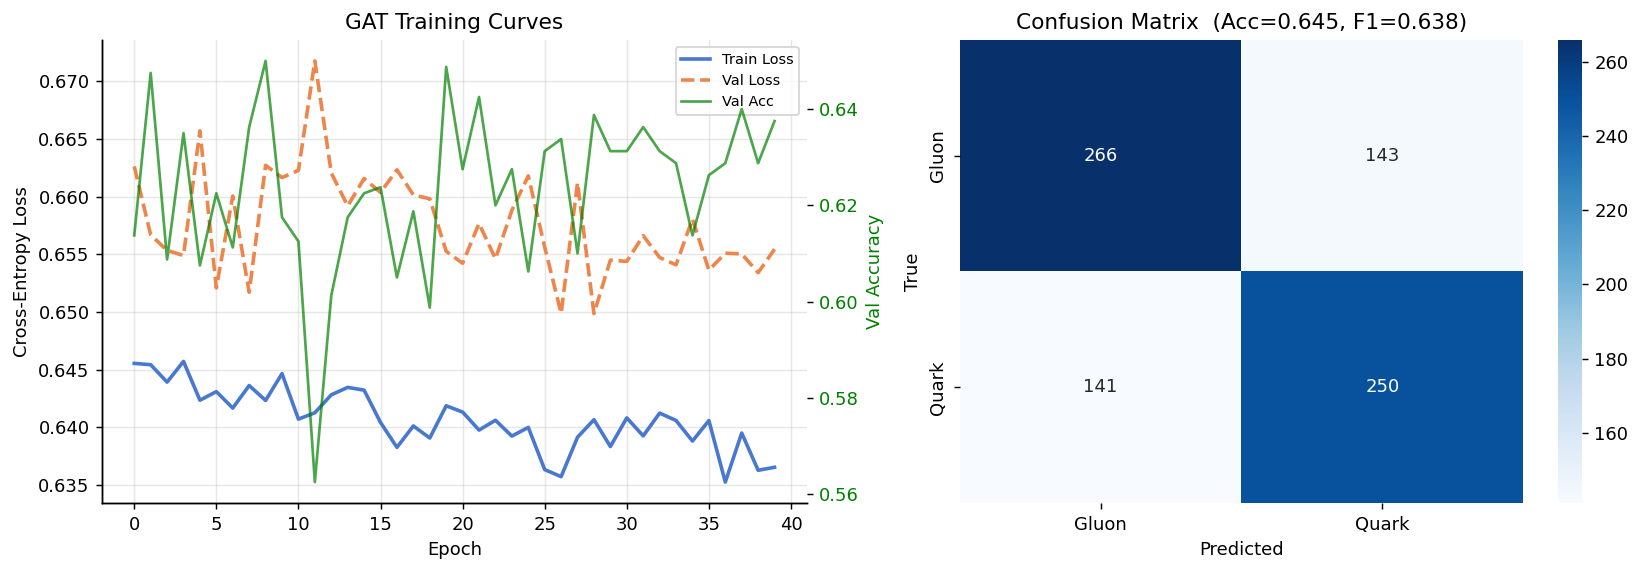

In [148]:
_, test_acc, test_true, test_pred = run_gnn_epoch(gnn, g_test_loader)
f1 = f1_score(test_true, test_pred, average='binary')
cm = confusion_matrix(test_true, test_pred)

print(f"\nGAT Classifier — Test Results")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  F1-Score  : {f1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(gnn_train_hist, lw=2, label='Train Loss')
axes[0].plot(gnn_val_hist,   lw=2, ls='--', label='Val Loss')
ax2 = axes[0].twinx()
ax2.plot(gnn_acc_hist, lw=1.5, color='green', alpha=0.7, label='Val Acc')
ax2.set_ylabel('Val Accuracy', color='green')
ax2.tick_params(axis='y', labelcolor='green')
axes[0].set_title('GAT Training Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
lines1, lab1 = axes[0].get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, lab1 + lab2, fontsize=8)
axes[0].grid(alpha=0.3)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Gluon', 'Quark'],
    yticklabels=['Gluon', 'Quark'],
    ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix  (Acc={test_acc:.3f}, F1={f1:.3f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

**Discussion**  

The initial GAT achieved ~60% accuracy and F1-score of ~0.6027 with K=8 and hidden size 128. Gradually increasing **K to 20**, **hidden size to 256**, and **attention heads to 8**, along with adding **edge features**, improved the model’s ability to capture graph structure, boosting accuracy to **64.50%** and F1-score to **0.6378**. This shows that tuning graph connectivity, model capacity, and incorporating relational information significantly enhances jet classification performance.

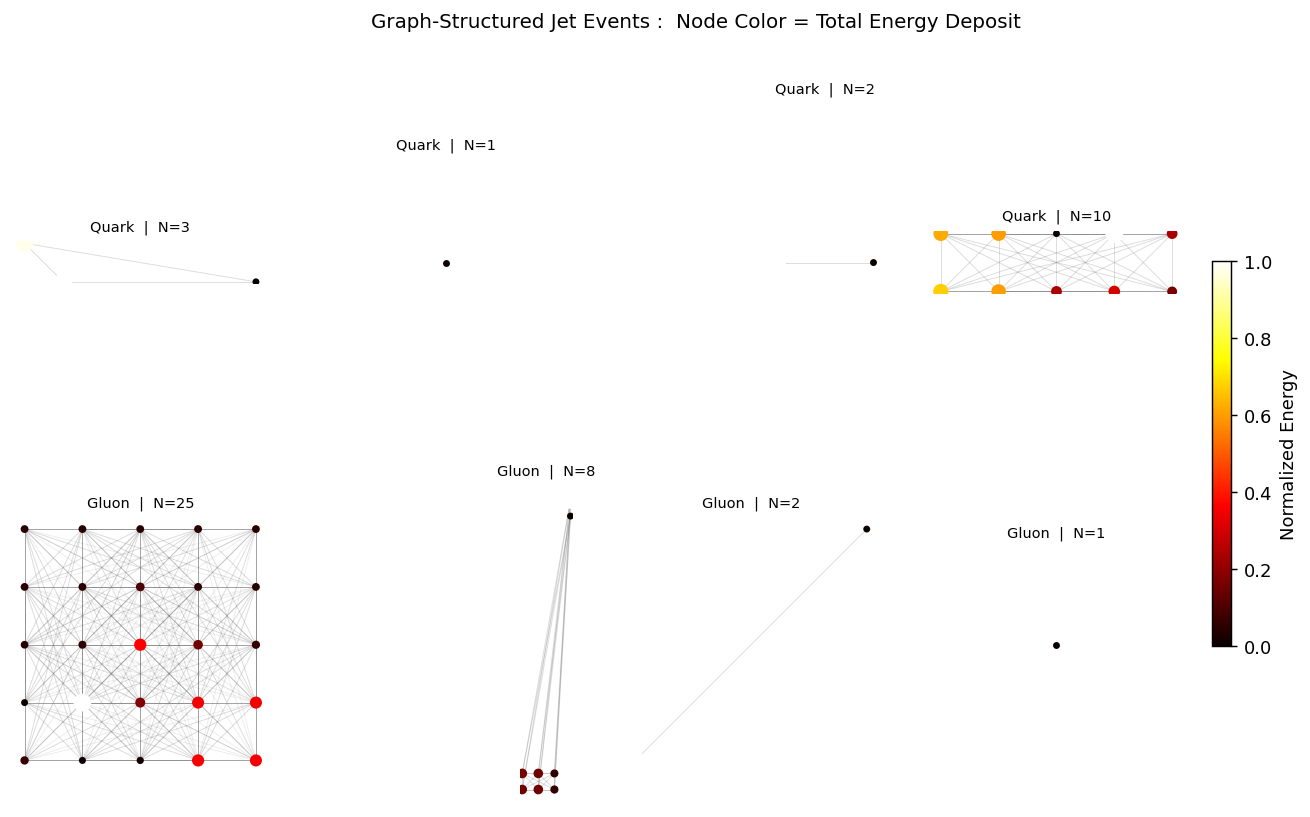

In [123]:
def draw_jet_graph(g, ax, title=''):
    pos   = g.pos.numpy()
    feats = g.x.numpy()
    ei    = g.edge_index.numpy()

    energy      = feats[:, 2:].sum(1)
    energy_norm = (energy - energy.min()) / (energy.max() - energy.min() + 1e-8)

    for k in range(ei.shape[1]):
        s, d = ei[0, k], ei[1, k]
        ax.plot([pos[s, 0], pos[d, 0]], [pos[s, 1], pos[d, 1]],
                color='gray', alpha=0.15, lw=0.5, zorder=1)

    sc = ax.scatter(pos[:, 0], pos[:, 1],
                    c=energy_norm, cmap='hot',
                    s=8 + energy_norm * 70,
                    vmin=0, vmax=1, zorder=2)
    ax.set_title(title, fontsize=8)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')
    return sc


quarks = [g for g in g_test[:300] if g.y.item() == 1][:4]
gluons = [g for g in g_test[:300] if g.y.item() == 0][:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Graph-Structured Jet Events :  Node Color = Total Energy Deposit', fontsize=11)

for i, g in enumerate(quarks):
    sc = draw_jet_graph(g, axes[0, i], f'Quark  |  N={g.num_nodes}')
for i, g in enumerate(gluons):
    sc = draw_jet_graph(g, axes[1, i], f'Gluon  |  N={g.num_nodes}')

axes[0, 0].set_ylabel('Quark Jets', fontsize=9)
axes[1, 0].set_ylabel('Gluon Jets', fontsize=9)

fig.colorbar(sc, ax=axes, shrink=0.55, pad=0.02, label='Normalized Energy')
plt.show()

---
## Task 3 : Graph Autoencoder for Detector Simulation


In [124]:
class GraphAutoencoder(nn.Module):
    def __init__(self, in_ch=5, hidden=64, latent=32):
        super().__init__()
        self.encoder = GraphEncoder(in_ch, hidden, latent)
        self.decoder = GraphDecoder(latent, hidden, in_ch)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return self.decoder(z, edge_index)


class GraphDecoder(nn.Module):
    def __init__(self, latent=32, hidden=64, out_ch=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent,  hidden),
            nn.ReLU(),
            nn.Linear(hidden,  hidden),
            nn.ReLU(),
            nn.Linear(hidden,  out_ch),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class GraphAutoencoder(nn.Module):
    def __init__(self, in_ch=5, hidden=64, latent=32):
        super().__init__()
        self.encoder = GraphEncoder(in_ch, hidden, latent)
        self.decoder = GraphDecoder(latent, hidden, in_ch)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return self.decoder(z)


gae = GraphAutoencoder().to(device)
print(f"Graph Autoencoder parameters: {sum(p.numel() for p in gae.parameters()):,}")

Graph Autoencoder parameters: 44,517


In [125]:
gae_opt   = torch.optim.Adam(gae.parameters(), lr=LR)
gae_sched = torch.optim.lr_scheduler.CosineAnnealingLR(gae_opt, T_max=GAE_EPOCHS)

gae_train_hist = []
gae_val_hist   = []


def run_gae_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    
    with ctx:
        for batch in loader:
            batch = batch.to(device)

            recon = model(batch.x, batch.edge_index)

            mask = (batch.x > 0).float()
            weights = 1.0 + (mask * 49.0) 
            
            loss = (weights * (recon - batch.x)**2).mean()
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
            total_loss += loss.item()
            
    return total_loss / len(loader)


print("Training Graph Autoencoder …")
for epoch in range(1, GAE_EPOCHS + 1):
    tr = run_gae_epoch(gae, g_train_loader, gae_opt)
    vl = run_gae_epoch(gae, g_val_loader)
    gae_sched.step()
    gae_train_hist.append(tr)
    gae_val_hist.append(vl)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{GAE_EPOCHS}  train={tr:.5f}  val={vl:.5f}")


Training Graph Autoencoder …
  Epoch   1/40  train=0.66828  val=0.04326
  Epoch   5/40  train=0.03529  val=0.03871
  Epoch  10/40  train=0.03291  val=0.03738
  Epoch  15/40  train=0.03145  val=0.03721
  Epoch  20/40  train=0.03059  val=0.03494
  Epoch  25/40  train=0.02971  val=0.03489
  Epoch  30/40  train=0.02990  val=0.03586
  Epoch  35/40  train=0.02959  val=0.03396
  Epoch  40/40  train=0.02921  val=0.03391


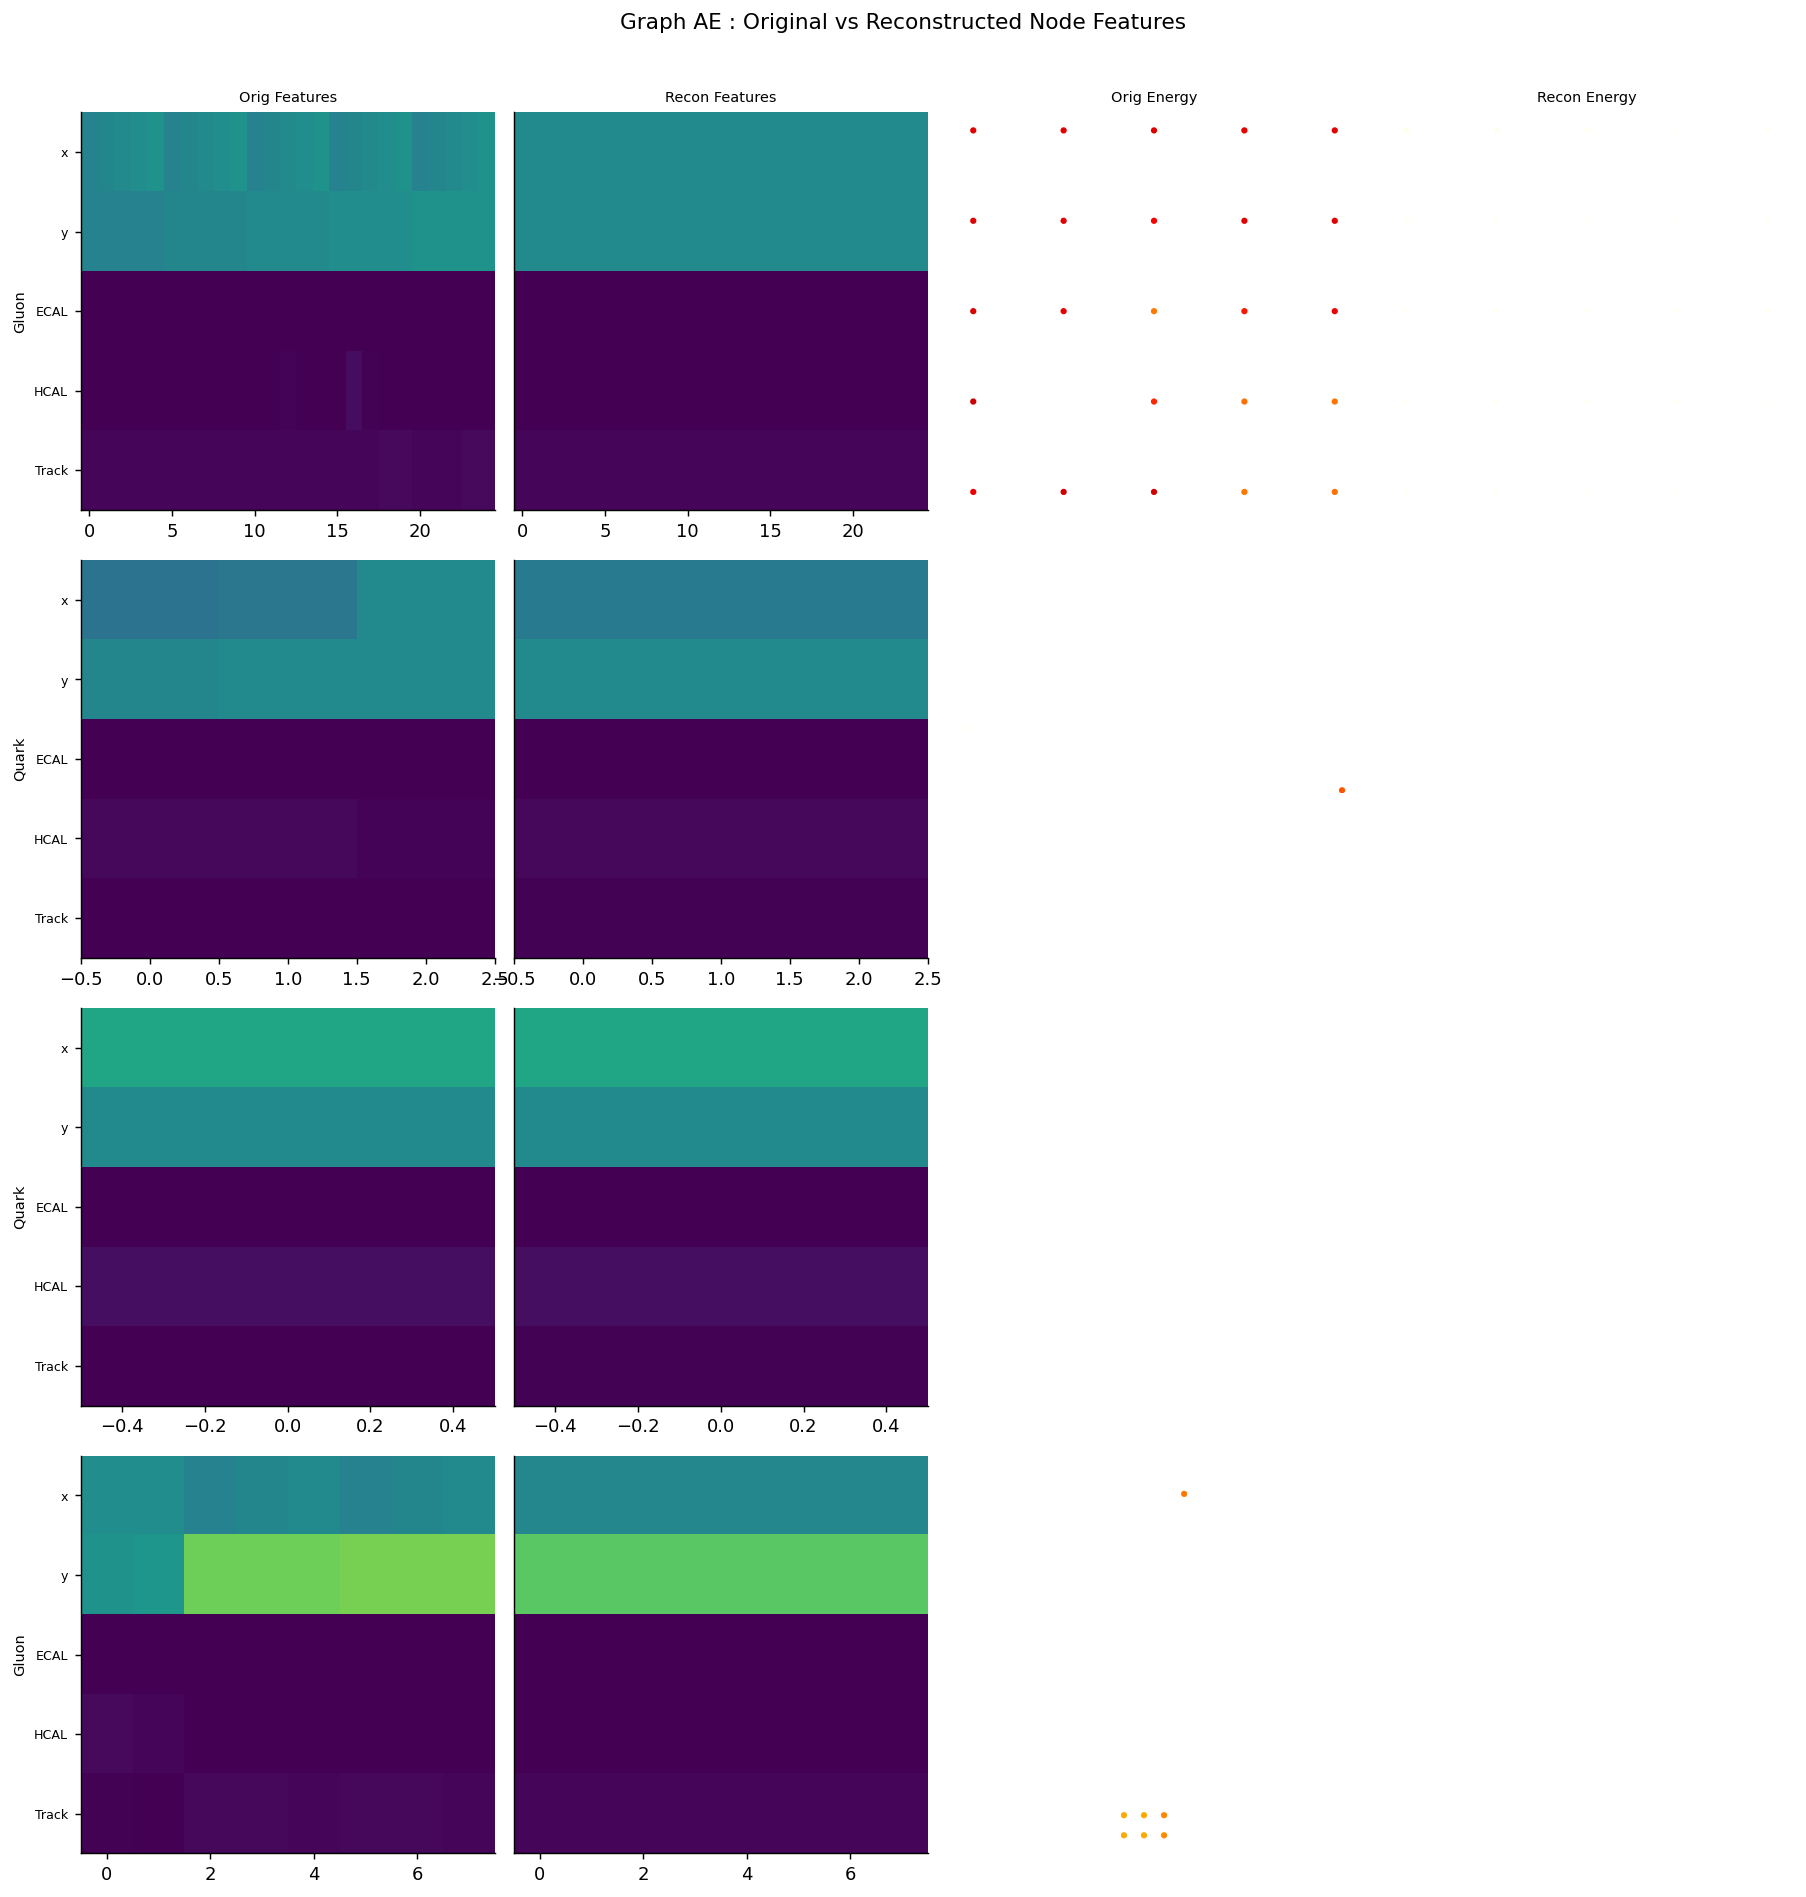

In [126]:
def visualize_gae_recon(model, graphs, n=4):
    model.eval()
    feat_labels = ['x', 'y', 'ECAL', 'HCAL', 'Track']

    fig = plt.figure(figsize=(14, n * 3.6))
    fig.suptitle('Graph AE : Original vs Reconstructed Node Features', fontsize=12, y=1.01)

    with torch.no_grad():
        for i, g in enumerate(graphs[:n]):
            g_dev = g.to(device)
            recon = model(g_dev.x, g_dev.edge_index).cpu().numpy()
            orig  = g.x.cpu().numpy()  
            pos   = g.pos.cpu().numpy()  
            label = LABEL_MAP[g.y.item()]

            ax1 = fig.add_subplot(n, 4, 4*i + 1)
            ax2 = fig.add_subplot(n, 4, 4*i + 2)
            ax3 = fig.add_subplot(n, 4, 4*i + 3)
            ax4 = fig.add_subplot(n, 4, 4*i + 4)

            ax1.imshow(orig.T,  aspect='auto', cmap='viridis', vmin=0, vmax=1)
            ax2.imshow(recon.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
            ax1.set_yticks(range(5))
            ax1.set_yticklabels(feat_labels, fontsize=7)
            ax2.set_yticks([])
            if i == 0:
                ax1.set_title('Orig Features', fontsize=8)
                ax2.set_title('Recon Features', fontsize=8)
                ax3.set_title('Orig Energy', fontsize=8)
                ax4.set_title('Recon Energy', fontsize=8)
            ax1.set_ylabel(label, fontsize=8)

            e_orig  = orig[:, 2:].sum(1)
            e_recon = recon[:, 2:].sum(1)
            ax3.scatter(pos[:, 0], pos[:, 1], c=e_orig,  cmap='hot', s=6, vmin=0)
            ax4.scatter(pos[:, 0], pos[:, 1], c=e_recon, cmap='hot', s=6, vmin=0)
            for ax in [ax3, ax4]:
                ax.invert_yaxis()
                ax.set_aspect('equal')
                ax.axis('off')

    plt.tight_layout()
    plt.show()
visualize_gae_recon(gae, g_test[:8])

---
## Comparison: Beta-VAE vs Graph Autoencoder



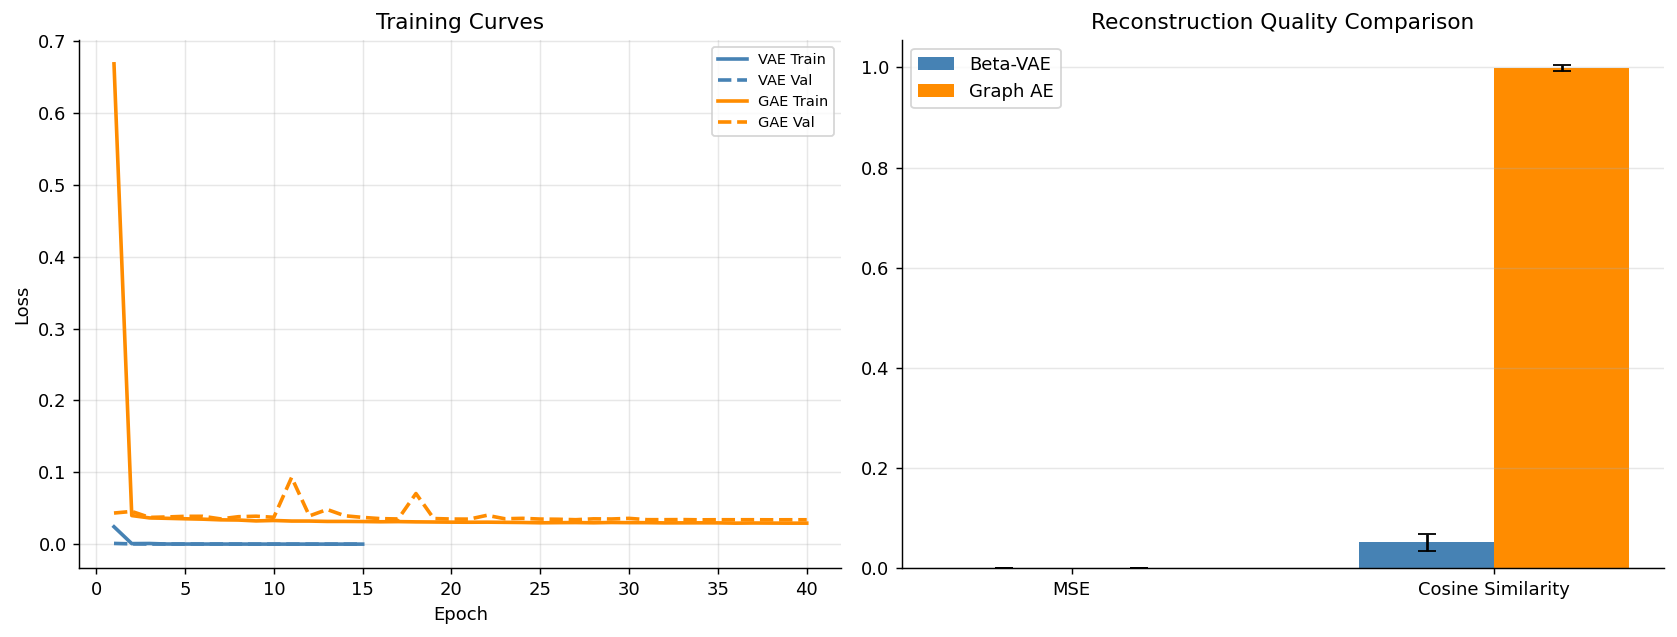

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, max(VAE_EPOCHS, GAE_EPOCHS) + 1)

axes[0].plot(range(1, VAE_EPOCHS + 1), vae_train_hist, lw=2, color='steelblue',  label='VAE Train')
axes[0].plot(range(1, VAE_EPOCHS + 1), vae_val_hist,   lw=2, color='steelblue',  ls='--', label='VAE Val')
axes[0].plot(range(1, GAE_EPOCHS + 1), gae_train_hist, lw=2, color='darkorange', label='GAE Train')
axes[0].plot(range(1, GAE_EPOCHS + 1), gae_val_hist,   lw=2, color='darkorange', ls='--', label='GAE Val')
axes[0].set_title('Training Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

metrics  = ['MSE', 'Cosine Similarity']
vae_vals = [vae_metrics['mse_mean'], vae_metrics['cos_mean']]
gae_vals = [gae_metrics['mse_mean'], gae_metrics['cos_mean']]
vae_err  = [vae_metrics['mse_std'],  vae_metrics['cos_std']]
gae_err  = [gae_metrics['mse_std'],  gae_metrics['cos_std']]

x = np.arange(len(metrics))
w = 0.32
axes[1].bar(x - w/2, vae_vals, w, yerr=vae_err, capsize=5,
            color='steelblue',  label='Beta-VAE')
axes[1].bar(x + w/2, gae_vals, w, yerr=gae_err, capsize=5,
            color='darkorange', label='Graph AE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Reconstruction Quality Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=130)
plt.show()